<a href="https://colab.research.google.com/github/fvangool/Deep-Learning-Specialization-Coursera/blob/main/Ensemblier_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold

# ============================================================
# 1. SETUP & DATA LOADING (Fixed y_train definition)
# ============================================================

TRAIN_PATH = "/content/drive/MyDrive/irrigation_need_v15/train.csv"
OOF_DIR = "/content/drive/MyDrive/irrigation_need_v15/"

print("Loading target labels...")
train_df = pd.read_csv(TRAIN_PATH)

# Use LabelEncoder to ensure 0, 1, 2 mapping (Alphabetical: High=0, Low=1, Medium=2)
le = LabelEncoder()
y_train = le.fit_transform(train_df['Irrigation_Need'])
print(f"Target classes: {list(le.classes_)} -> [0, 1, 2]")

FILES = {
    "lgbm"      : (f"{OOF_DIR}oof_lgbm_biased.npy",      f"{OOF_DIR}pred_lgbm_biased.npy"),
    "xgb_v18"   : (f"{OOF_DIR}oof_xgb_v18ms.npy",       f"{OOF_DIR}pred_xgb_v18ms.npy"),
    "cat_v18"   : (f"{OOF_DIR}oof_cat_v18.npy",         f"{OOF_DIR}pred_cat_v18.npy"),
    "realmlp"   : (f"{OOF_DIR}oof_realmlp_biased.npy",   f"{OOF_DIR}pred_realmlp_biased.npy"),
    "ftt"       : (f"{OOF_DIR}oof_ftt_v2.npy",           f"{OOF_DIR}pred_ftt_v2.npy"),
    "gnn"       : (f"{OOF_DIR}oof_gnn_v1.npy",           f"{OOF_DIR}pred_gnn_v1.npy"),
    "autolguon" : (f"{OOF_DIR}oof_autogluon_v1.npy",     f"{OOF_DIR}pred_autogluon_v1.npy"),
    "tabm"      : (f"{OOF_DIR}oof_tabm_v5_biased.npy",   f"{OOF_DIR}pred_tabm_v5_biased.npy"),
    "extratrees": (f"{OOF_DIR}oof_extratrees.npy",        f"{OOF_DIR}pred_extratrees.npy"),
}
"""
oofs = []
preds = []
for name, (oof_path, pred_path) in FILES.items():
    if os.path.exists(oof_path):
        oofs.append(np.load(oof_path))
        preds.append(np.load(pred_path))
        print(f"✅ Loaded {name}")
    else:
        print(f"❌ Missing {name} at {oof_path}")
"""
# ============================================================
# 1. UPDATED LOADING WITH ALIGNMENT FIX
# ============================================================
target_len = len(y_train)  # This is 630,000
oofs = []
preds = []
final_model_names = []

print(f"Targeting {target_len} rows for OOF alignment...")

for name, (oof_path, pred_path) in FILES.items():
    if os.path.exists(oof_path):
        oof_arr = np.load(oof_path)
        pred_arr = np.load(pred_path)

        # Check for row mismatch
        if len(oof_arr) != target_len:
            if len(oof_arr) > target_len:
                print(f"⚠️  {name:<12}: Slicing {len(oof_arr)} -> {target_len} (assuming original data was appended)")
                oof_arr = oof_arr[:target_len]
            else:
                print(f"❌ {name:<12}: Error! OOF size {len(oof_arr)} is too small. Skipping.")
                continue

        oofs.append(oof_arr)
        preds.append(pred_arr)
        final_model_names.append(name)
        print(f"✅ {name:<12}: Loaded and Aligned")
    else:
        print(f"❌ {name:<12}: Missing files")

# Ensure we actually have models to stack
if not oofs:
    raise ValueError("No valid OOF files loaded. Check your paths and file sizes.")
# ============================================================
# 2. ENSEMBLE FUNCTIONS
# ============================================================

def lgb_stacker(oof_list, pred_list, y_true, n_splits=5, seed=42):
    X_oof = np.hstack(oof_list)
    X_test = np.hstack(pred_list)

    oof_proba = np.zeros((len(y_true), 3))
    test_probas = []

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    params = {
        "objective": "multiclass", "num_class": 3, "metric": "multi_logloss",
        "learning_rate": 0.05, "num_leaves": 31, "verbose": -1, "seed": seed
    }

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_oof, y_true)):
        dtrain = lgb.Dataset(X_oof[tr_idx], label=y_true[tr_idx])
        dval = lgb.Dataset(X_oof[va_idx], label=y_true[va_idx], reference=dtrain)

        model = lgb.train(params, dtrain, num_boost_round=1000,
                          valid_sets=[dval], callbacks=[lgb.early_stopping(50)])

        oof_proba[va_idx] = model.predict(X_oof[va_idx])
        test_probas.append(model.predict(X_test))

    return oof_proba, np.mean(test_probas, axis=0)

def tune_bias_log(proba, y_true):
    def preds_from_bias(bias):
        return np.argmax(np.log(np.clip(proba, 1e-15, 1.0)) + bias, axis=1)

    best_bias = np.zeros(3)
    best_score = balanced_accuracy_score(y_true, preds_from_bias(best_bias))

    for step in (1.0, 0.5, 0.1, 0.01):
        improved = True
        while improved:
            improved = False
            for ci in range(3):
                for d in (-1, 1):
                    cand = best_bias.copy()
                    cand[ci] += d * step
                    s = balanced_accuracy_score(y_true, preds_from_bias(cand))
                    if s > best_score:
                        best_bias, best_score, improved = cand, s, True
    return best_bias, best_score

# ============================================================
# 3. EXECUTION
# ============================================================
print("\nRunning Stacker...")
stack_oof, stack_test = lgb_stacker(oofs, preds, y_train)

print("Optimizing decision boundaries...")
best_bias, final_cv = tune_bias_log(stack_oof, y_train)

print(f"\n{'='*30}")
print(f"FINAL STACKER CV: {final_cv:.6f}")
print(f"BEST BIASES: {best_bias}")
print(f"{'='*30}")

# Final Prediction Generation
final_probs = np.log(np.clip(stack_test, 1e-15, 1.0)) + best_bias
final_labels = le.inverse_transform(final_probs.argmax(axis=1))

# Save
submission = pd.read_csv("/content/drive/MyDrive/irrigation_need_v15/sample_submission.csv")
submission['Irrigation_Need'] = final_labels
submission.to_csv("stacker_submission.csv", index=False)
print("Done! Submission saved as stacker_submission.csv")

Loading target labels...
Target classes: ['High', 'Low', 'Medium'] -> [0, 1, 2]
Targeting 630000 rows for OOF alignment...
✅ lgbm        : Loaded and Aligned
✅ xgb_v18     : Loaded and Aligned
✅ cat_v18     : Loaded and Aligned
✅ realmlp     : Loaded and Aligned
✅ ftt         : Loaded and Aligned
✅ gnn         : Loaded and Aligned
⚠️  autolguon   : Slicing 640000 -> 630000 (assuming original data was appended)
✅ autolguon   : Loaded and Aligned
✅ tabm        : Loaded and Aligned
✅ extratrees  : Loaded and Aligned

Running Stacker...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[196]	valid_0's multi_logloss: 0.0428213
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[143]	valid_0's multi_logloss: 0.0442426
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[164]	valid_0's multi_logloss: 0.0441961
Training until validation scores don't improve for

WEIGHTED STACKING

In [ ]:
import numpy as np
import pandas as pd
import os
from scipy.optimize import minimize
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder

# ============================================================
# 1. SETUP & ALIGNED LOADING (Reusing your previous logic)
# ============================================================
OOF_DIR = "/content/drive/MyDrive/irrigation_need_v15/"
TRAIN_PATH = f"{OOF_DIR}train.csv"

# Load Ground Truth
train_df = pd.read_csv(TRAIN_PATH)
le = LabelEncoder()
y_train = le.fit_transform(train_df['Irrigation_Need']) # 0:High, 1:Low, 2:Medium
target_len = len(y_train)

FILES = {
    "lgbm": (f"{OOF_DIR}oof_lgbm_biased.npy", f"{OOF_DIR}pred_lgbm_biased.npy"),
    "xgb_v18": (f"{OOF_DIR}oof_xgb_v18ms.npy", f"{OOF_DIR}pred_xgb_v18ms.npy"),
    "cat_v18": (f"{OOF_DIR}oof_cat_v18.npy", f"{OOF_DIR}pred_cat_v18.npy"),
    "realmlp": (f"{OOF_DIR}oof_realmlp_biased.npy", f"{OOF_DIR}pred_realmlp_biased.npy"),
    "ftt": (f"{OOF_DIR}oof_ftt_v2.npy", f"{OOF_DIR}pred_ftt_v2.npy"),
    "gnn": (f"{OOF_DIR}oof_gnn_v1.npy", f"{OOF_DIR}pred_gnn_v1.npy"),
    "autogluon": (f"{OOF_DIR}oof_autogluon_v1.npy", f"{OOF_DIR}pred_autogluon_v1.npy"),
    "tabm": (f"{OOF_DIR}oof_tabm_v5_biased.npy", f"{OOF_DIR}pred_tabm_v5_biased.npy"),
    "extratrees": (f"{OOF_DIR}oof_extratrees.npy", f"{OOF_DIR}pred_extratrees.npy"),
}

oofs, preds, active_models = [], [], []

for name, (oof_path, pred_path) in FILES.items():
    if os.path.exists(oof_path):
        o_arr = np.load(oof_path)[:target_len] # Ensure alignment
        p_arr = np.load(pred_path)
        oofs.append(o_arr)
        preds.append(p_arr)
        active_models.append(name)
        print(f"✅ {name:<12} Loaded")

# ============================================================
# 2. WEIGHT OPTIMIZATION
# ============================================================

def objective(weights, oofs, y_true):
    # Ensure weights sum to 1 (handled by constraints in minimize)
    weighted_probs = np.zeros_like(oofs[0])
    for i in range(len(weights)):
        weighted_probs += weights[i] * oofs[i]

    # Get hard classes and calculate Balanced Accuracy
    preds = np.argmax(weighted_probs, axis=1)
    # We return negative BA because minimize find the minimum
    return -balanced_accuracy_score(y_true, preds)

print(f"\nOptimizing weights for {len(active_models)} models...")

# Constraints: Weights must sum to 1.0 and each weight must be between 0 and 1
cons = ({'type': 'eq', 'fun': lambda w: 1.0 - np.sum(w)})
bounds = [(0, 1)] * len(active_models)
init_guess = [1.0 / len(active_models)] * len(active_models)

res = minimize(
    objective,
    init_guess,
    args=(oofs, y_train),
    method='SLSQP',
    bounds=bounds,
    constraints=cons,
    tol=1e-6
)

best_weights = res.x
print("\n--- OPTIMIZED WEIGHTS ---")
for name, weight in zip(active_models, best_weights):
    if weight > 0.001: # Only show contributors
        print(f"{name:<12}: {weight:.4f}")

# ============================================================
# 3. GENERATE FINAL PREDICTIONS
# ============================================================

# Calculate Weighted OOF for score verification
final_oof_probs = np.zeros_like(oofs[0])
for i in range(len(best_weights)):
    final_oof_probs += best_weights[i] * oofs[i]

final_cv = balanced_accuracy_score(y_train, final_oof_probs.argmax(axis=1))
print(f"\nFinal Weighted Ensemble CV: {final_cv:.6f}")

# Apply to Test Set
final_test_probs = np.zeros_like(preds[0])
for i in range(len(best_weights)):
    final_test_probs += best_weights[i] * preds[i]

# Final Submission
submission = pd.read_csv(f"{OOF_DIR}sample_submission.csv")
submission['Irrigation_Need'] = le.inverse_transform(final_test_probs.argmax(axis=1))
submission.to_csv("weighted_ensemble_submission.csv", index=False)
print("\n✅ Success! Weighted ensemble saved.")

✅ lgbm         Loaded
✅ xgb_v18      Loaded
✅ cat_v18      Loaded
✅ realmlp      Loaded
✅ ftt          Loaded
✅ gnn          Loaded
✅ autogluon    Loaded
✅ tabm         Loaded
✅ extratrees   Loaded

Optimizing weights for 9 models...

--- OPTIMIZED WEIGHTS ---
lgbm        : 0.1111
xgb_v18     : 0.1111
cat_v18     : 0.1111
realmlp     : 0.1111
ftt         : 0.1111
gnn         : 0.1111
autogluon   : 0.1111
tabm        : 0.1111
extratrees  : 0.1111

Final Weighted Ensemble CV: 0.006063

✅ Success! Weighted ensemble saved.


In [ ]:
for i, name in enumerate(active_models):
    # Check if the raw OOF of each model matches y_train
    raw_score = balanced_accuracy_score(y_train, oofs[i].argmax(axis=1))
    print(f"Model: {name:<12} | Raw OOF BA: {raw_score:.5f}")

Model: lgbm         | Raw OOF BA: 0.00585
Model: xgb_v18      | Raw OOF BA: 0.00658
Model: cat_v18      | Raw OOF BA: 0.00667
Model: realmlp      | Raw OOF BA: 0.00558
Model: ftt          | Raw OOF BA: 0.00760
Model: gnn          | Raw OOF BA: 0.96488
Model: autogluon    | Raw OOF BA: 0.96773
Model: tabm         | Raw OOF BA: 0.00415
Model: extratrees   | Raw OOF BA: 0.00357


In [ ]:
import numpy as np
from sklearn.metrics import balanced_accuracy_score

# 1. Define the correct y_train (using Alphabetical to match GNN/AutoGluon)
# (Assuming train_df and y_train are already defined as Alphabetical)

aligned_oofs = []
aligned_preds = []

# This is the "Magic Swap" map.
# We need to move the columns of the 7 "broken" models to match the 2 "good" ones.
# Based on common mappings, you likely need to swap indices.
# Let's try the most common swap: [Low, Med, High] -> [High, Low, Med]

for i, name in enumerate(active_models):
    oof_copy = oofs[i].copy()
    pred_copy = preds[i].copy()

    if name in ['gnn', 'autogluon']:
        # These are already correct (0.96 BA)
        print(f"✅ {name}: Keeping original mapping")
        aligned_oofs.append(oof_copy)
        aligned_preds.append(pred_copy)
    else:
        # These are at 0.005 BA - we must reorder their columns
        # We will try all 6 possible permutations and pick the one that hits 0.90+ BA
        best_ba = 0
        best_perm = [0, 1, 2]

        import itertools
        for p in itertools.permutations([0, 1, 2]):
            permuted_oof = oof_copy[:, p]
            score = balanced_accuracy_score(y_train, permuted_oof.argmax(axis=1))
            if score > best_ba:
                best_ba = score
                best_perm = p

        print(f"🔄 {name}: Fixed! Permutation {best_perm} raised BA to {best_ba:.5f}")
        aligned_oofs.append(oof_copy[:, best_perm])
        aligned_preds.append(pred_copy[:, best_perm])

# Now use 'aligned_oofs' and 'aligned_preds' in your Stacker/Weighted Stacker!

🔄 lgbm: Fixed! Permutation (2, 0, 1) raised BA to 0.97945
🔄 xgb_v18: Fixed! Permutation (2, 0, 1) raised BA to 0.97954
🔄 cat_v18: Fixed! Permutation (2, 0, 1) raised BA to 0.97935
🔄 realmlp: Fixed! Permutation (2, 0, 1) raised BA to 0.97807
🔄 ftt: Fixed! Permutation (2, 0, 1) raised BA to 0.96758
✅ gnn: Keeping original mapping
✅ autogluon: Keeping original mapping
🔄 tabm: Fixed! Permutation (2, 0, 1) raised BA to 0.96427
🔄 extratrees: Fixed! Permutation (2, 0, 1) raised BA to 0.96114


# **Complete auto align stacker (WAS WINNING NOT ANYMORE)**

In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import os
import itertools
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold

# ============================================================
# 1. SETUP & LOADING
# ============================================================
OOF_DIR = "/content/drive/MyDrive/irrigation_need_v15/"
train_df = pd.read_csv(f"{OOF_DIR}train.csv")

# Use Alphabetical Mapping (High=0, Low=1, Medium=2) to match GNN/AutoGluon
le = LabelEncoder()
y_train = le.fit_transform(train_df['Irrigation_Need'])
target_len = len(y_train)

FILES = {
    "lgbm"      : (f"{OOF_DIR}oof_lgbm_biased.npy",      f"{OOF_DIR}pred_lgbm_biased.npy"),
    "xgb_v18"   : (f"{OOF_DIR}oof_xgb_v18ms.npy",       f"{OOF_DIR}pred_xgb_v18ms.npy"),
    "cat_v18"   : (f"{OOF_DIR}oof_cat_v18.npy",         f"{OOF_DIR}pred_cat_v18.npy"),
    "realmlp"   : (f"{OOF_DIR}oof_realmlp_biased.npy",   f"{OOF_DIR}pred_realmlp_biased.npy"),
    "ftt"       : (f"{OOF_DIR}oof_ftt_v2.npy",           f"{OOF_DIR}pred_ftt_v2.npy"),
    "gnn"       : (f"{OOF_DIR}oof_gnn_v1.npy",           f"{OOF_DIR}pred_gnn_v1.npy"),
    "autolguon" : (f"{OOF_DIR}oof_autogluon_v1.npy",     f"{OOF_DIR}pred_autogluon_v1.npy"),
    "tabm"      : (f"{OOF_DIR}oof_tabm_v5_biased.npy",   f"{OOF_DIR}pred_tabm_v5_biased.npy"),
    "extratrees": (f"{OOF_DIR}oof_extratrees.npy",        f"{OOF_DIR}pred_extratrees.npy"),
}

raw_oofs, raw_preds, model_names = [], [], []

for name, (oof_p, pred_p) in FILES.items():
    if os.path.exists(oof_p):
        o_arr = np.load(oof_p)[:target_len] # Row Alignment fix
        p_arr = np.load(pred_p)
        raw_oofs.append(o_arr)
        raw_preds.append(p_arr)
        model_names.append(name)

# ============================================================
# 2. THE "MAGIC SWAP" CORRECTION LAYER
# ============================================================
print("--- Aligning Model Probabilities ---")
aligned_oofs = []
aligned_preds = []

for i, name in enumerate(model_names):
    best_ba = 0
    best_perm = (0, 1, 2)

    # Try all 6 permutations of [Class 0, Class 1, Class 2]
    for p in itertools.permutations([0, 1, 2]):
        score = balanced_accuracy_score(y_train, raw_oofs[i][:, p].argmax(axis=1))
        if score > best_ba:
            best_ba = score
            best_perm = p

    print(f"✅ {name:<12} aligned (BA: {best_ba:.5f}) using perm {best_perm}")
    aligned_oofs.append(raw_oofs[i][:, best_perm])
    aligned_preds.append(raw_preds[i][:, best_perm])

# ============================================================
# 3. STACKING & POST-PROCESSING FUNCTIONS
# ============================================================

def lgb_stacker(oof_list, pred_list, y_true):
    X_oof = np.hstack(oof_list) # Uses the corrected ALIGNED list
    X_test = np.hstack(pred_list)

    oof_probs = np.zeros((len(y_true), 3))
    test_probs = []

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    params = {"objective": "multiclass", "num_class": 3, "metric": "multi_logloss",
              "learning_rate": 0.05, "num_leaves": 31, "verbose": -1}

    for tr_idx, va_idx in skf.split(X_oof, y_true):
        dtr = lgb.Dataset(X_oof[tr_idx], label=y_true[tr_idx])
        dva = lgb.Dataset(X_oof[va_idx], label=y_true[va_idx], reference=dtr)
        model = lgb.train(params, dtr, 1000, valid_sets=[dva], callbacks=[lgb.early_stopping(50)])
        oof_probs[va_idx] = model.predict(X_oof[va_idx])
        test_probs.append(model.predict(X_test))

    return oof_probs, np.mean(test_probs, axis=0)

def tune_bias(proba, y_true):
    def get_score(b): return balanced_accuracy_score(y_true, np.argmax(np.log(np.clip(proba, 1e-15, 1)) + b, axis=1))
    best_bias = np.zeros(3)
    best_s = get_score(best_bias)
    for step in [1.0, 0.5, 0.1, 0.01]:
        for _ in range(20):
            improved = False
            for i in range(3):
                for d in [-step, step]:
                    tmp = best_bias.copy(); tmp[i] += d
                    s = get_score(tmp)
                    if s > best_s: best_s, best_bias, improved = s, tmp, True
            if not improved: break
    return best_bias, best_s

# ============================================================
# 4. FINAL EXECUTION
# ============================================================
print("\n--- Training LightGBM Stacker ---")
stack_oof, stack_test = lgb_stacker(aligned_oofs, aligned_preds, y_train)

print("\n--- Tuning Log-Bias ---")
best_b, final_cv = tune_bias(stack_oof, y_train)

print(f"\nFINAL STACKER CV: {final_cv:.6f}")

# Save Submission
final_probs = np.log(np.clip(stack_test, 1e-15, 1.0)) + best_b
final_labels = le.inverse_transform(final_probs.argmax(axis=1))

sub = pd.read_csv(f"{OOF_DIR}sample_submission.csv")
sub['Irrigation_Need'] = final_labels
sub.to_csv("stacker_submission_aligned.csv", index=False)
print("Done! Submission saved.")

--- Aligning Model Probabilities ---
✅ lgbm         aligned (BA: 0.97945) using perm (2, 0, 1)
✅ xgb_v18      aligned (BA: 0.97954) using perm (2, 0, 1)
✅ cat_v18      aligned (BA: 0.97935) using perm (2, 0, 1)
✅ realmlp      aligned (BA: 0.97807) using perm (2, 0, 1)
✅ ftt          aligned (BA: 0.96758) using perm (2, 0, 1)
✅ gnn          aligned (BA: 0.96488) using perm (0, 1, 2)
✅ autolguon    aligned (BA: 0.96773) using perm (0, 1, 2)
✅ tabm         aligned (BA: 0.96427) using perm (2, 0, 1)
✅ extratrees   aligned (BA: 0.96114) using perm (2, 0, 1)

--- Training LightGBM Stacker ---
Training until validation scores don't improve for 50 rounds


KeyboardInterrupt: 

# **Add complexity (BEST SOLUTION)**

In [ ]:

# Emergency fix inside your ensemble script:
import numpy as np

nn_oofs = np.load('/content/drive/MyDrive/irrigation_need_v15/oof_nn_v3.npy').astype(int)
# Convert 1D labels to 2D one-hot (Shape: 630000, 3)
nn_oofs_2d = np.eye(3)[nn_oofs]

# Use nn_oofs_2d in your ensembling loop
import os
import numpy as np

# Define your save path
save_path = '/content/drive/MyDrive/irrigation_need_v15/oof_nn_v3_2D.npy'

# Optional: Create the directory if it doesn't exist
os.makedirs(os.path.dirname(save_path), exist_ok=True)

# Save the 2D array
np.save(save_path, nn_oofs_2d)

print(f"Saved successfully to: {save_path}")


Saved successfully to: /content/drive/MyDrive/irrigation_need_v15/oof_nn_v3_2D.npy


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import os
import itertools
from scipy.stats import rankdata
from scipy.optimize import differential_evolution
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder


# ============================================================
# 1. SETUP & LOADING (With Row Alignment)
# ============================================================
OOF_DIR = "/content/drive/MyDrive/irrigation_need_v15/"
train_df = pd.read_csv(f"{OOF_DIR}train.csv")

le = LabelEncoder()
y_train = le.fit_transform(train_df['Irrigation_Need'])
target_len = len(y_train)

FILES = {
    "lgbm"      : (f"{OOF_DIR}oof_lgbm_baseline.npy",      f"{OOF_DIR}pred_lgbm_baseline.npy"),
    "xgb_v18"   : (f"{OOF_DIR}oof_xgb_v22_biased.npy",       f"{OOF_DIR}pred_xgb_v22_biased.npy"),
    "cat_v18"   : (f"{OOF_DIR}oof_cat_v18.npy",         f"{OOF_DIR}pred_cat_v18.npy"),
    "realmlp"   : (f"{OOF_DIR}oof_realmlp_biased.npy",   f"{OOF_DIR}pred_realmlp_biased.npy"),
    "ftt"       : (f"{OOF_DIR}oof_ftt_v2.npy",           f"{OOF_DIR}pred_ftt_v2.npy"),
    "gnn"       : (f"{OOF_DIR}oof_gnn_v1.npy",           f"{OOF_DIR}pred_gnn_v1.npy"),
    "autolguon" : (f"{OOF_DIR}oof_autogluon_v1.npy",     f"{OOF_DIR}pred_autogluon_v1.npy"),
    "tabm"      : (f"{OOF_DIR}oof_tabm_v5_biased.npy",   f"{OOF_DIR}pred_tabm_v5_biased.npy"),
    "extratrees": (f"{OOF_DIR}oof_extratrees.npy",        f"{OOF_DIR}pred_extratrees.npy"),
    "log_reg": (f"{OOF_DIR}oof_logreg.npy",        f"{OOF_DIR}pred_logreg.npy"), #downgrades score
     "NN": (f"{OOF_DIR}oof_nn_v6_enhanced.npy",        f"{OOF_DIR}pred_nn_v6_enhanced.npy"), #downgrades score
     "xgb_cud": (f"{OOF_DIR}oof_xgb_cudf_001.npy",        f"{OOF_DIR}pred_xgb_cudf_001.npy"), #downgrades score
     "KNN": (f"{OOF_DIR}oof_knn_v1.npy",        f"{OOF_DIR}pred_knn_v1.npy"), #downgrades score
     "SVG": (f"{OOF_DIR}oof_svm_rbf_gpu_v1.npy",        f"{OOF_DIR}pred_svm_rbf_gpu_v1.npy"), #downgrades score

}

raw_oofs, raw_preds, model_names = [], [], []
for name, (oof_p, pred_p) in FILES.items():
    if os.path.exists(oof_p):
        raw_oofs.append(np.load(oof_p)[:target_len])
        raw_preds.append(np.load(pred_p))
        model_names.append(name)


# ============================================================
# 2. ALIGNMENT (The "Magic Swap")
# ============================================================
print("--- Aligning Model Probabilities ---")
aligned_oofs, aligned_preds = [], []
for i, name in enumerate(model_names):
    best_ba, best_perm = 0, (0, 1, 2)
    for p in itertools.permutations([0, 1, 2]):
        score = balanced_accuracy_score(y_train, raw_oofs[i][:, p].argmax(axis=1))
        if score > best_ba:
            best_ba, best_perm = score, p
    print(f"✅ {name:<12} (BA: {best_ba:.5f})")
    aligned_oofs.append(raw_oofs[i][:, best_perm])
    aligned_preds.append(raw_preds[i][:, best_perm])

# ============================================================
# 3. ENSEMBLE FUNCTIONS
# ============================================================

def get_rank_probs(probs):
    """Normalized rank-based probabilities."""
    ranked = np.zeros_like(probs)
    for i in range(probs.shape[1]):
        ranked[:, i] = rankdata(probs[:, i], method='min')
    return ranked / ranked.max()

def lgb_stacker_seeded(oof_list, pred_list, y_true, seed=42):
    X_oof = np.hstack(oof_list)
    X_test = np.hstack(pred_list)
    oof_probs = np.zeros((len(y_true), 3))
    test_probs = []
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    #params = {"objective": "multiclass", "num_class": 3, "metric": "multi_logloss",
    #          "learning_rate": 0.05, "num_leaves": 31, "verbose": -1, "seed": seed}
    params = {
      "objective": "multiclass",
      "num_class": 3,
      "metric": "multi_logloss",
      "learning_rate": 0.005,    # Dropped from 0.03 to be extremely conservative
      "num_leaves": 7,           # Tiny trees prevent memorizing the OOF noise
      "feature_fraction": 0.5,   # Force it to only see half the models per split
      "lambda_l1": 5.0,          # Heavy L1 to zero out unhelpful model-class signals
      "lambda_l2": 10.0,         # Heavy L2 to stabilize the weights
      "verbose": -1,
      "seed": seed
  }
    for tr_idx, va_idx in skf.split(X_oof, y_true):
        dtr = lgb.Dataset(X_oof[tr_idx], label=y_true[tr_idx])
        dva = lgb.Dataset(X_oof[va_idx], label=y_true[va_idx], reference=dtr)
        model = lgb.train(params, dtr, 1000, valid_sets=[dva],
                          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
        oof_probs[va_idx] = model.predict(X_oof[va_idx])
        test_probs.append(model.predict(X_test))
    return oof_probs, np.mean(test_probs, axis=0)

def diffevol_thresholds(proba, y_true):
    def neg_ba(weights):
        return -balanced_accuracy_score(y_true, (proba * weights).argmax(axis=1))
    print("Optimizing thresholds with Differential Evolution...")
    res = differential_evolution(neg_ba, bounds=[(0.2, 5.0)] * 3, seed=42, popsize=15)
    return res.x, -res.fun

# ============================================================
# 4. EXECUTION: SEED AVERAGING + RANK BLENDING
# ============================================================
seeds = seeds = [42, 1337, 2024, 7, 88, 99, 123, 456, 789, 10]# was [42, 1337, 2024] # You can add more seeds for more stability
all_oof_results, all_test_results = [], []

print(f"\n--- Running Seed-Averaged Stacker ({len(seeds)} seeds) ---")
for s in seeds:
    print(f"Training Seed {s}...")
    o_res, t_res = lgb_stacker_seeded(aligned_oofs, aligned_preds, y_train, seed=s)
    all_oof_results.append(o_res)
    all_test_results.append(t_res)

avg_stack_oof = np.mean(all_oof_results, axis=0)
avg_stack_test = np.mean(all_test_results, axis=0)

print("\n--- Applying Rank Blending ---")
# Using the best model (index 0) for rank blending diversity
best_model_test_rank = get_rank_probs(aligned_preds[0])
best_model_oof_rank = get_rank_probs(aligned_oofs[0])

# Final blend: Combine probabilities with ranks
#final_oof_probs = (avg_stack_oof * 0.75) + (best_model_oof_rank * 0.25)
#final_test_probs = (avg_stack_test * 0.75) + (best_model_test_rank * 0.25)
# Change the blend to favor the Stacker almost entirely
final_oof_probs = (avg_stack_oof * 0.95) + (best_model_oof_rank * 0.05)
final_test_probs = (avg_stack_test * 0.95) + (best_model_test_rank * 0.05)

# ============================================================
# 5. THRESHOLD OPTIMIZATION & SUBMISSION
# ============================================================
best_weights, final_cv = diffevol_thresholds(final_oof_probs, y_train)

print("\n" + "="*40)
print(f"ULTIMATE ENSEMBLE CV: {final_cv:.6f}")
print("="*40)

final_test_output = (final_test_probs * best_weights).argmax(axis=1)
final_labels = le.inverse_transform(final_test_output)

sub = pd.read_csv(f"{OOF_DIR}sample_submission.csv")
sub['Irrigation_Need'] = final_labels
sub.to_csv("grandmaster_ensemble_v2.csv", index=False)
print("\n✅ Final submission saved as grandmaster_ensemble_v2.csv")

--- Aligning Model Probabilities ---
✅ lgbm         (BA: 0.97922)
✅ xgb_v18      (BA: 0.97941)
✅ cat_v18      (BA: 0.97935)
✅ realmlp      (BA: 0.97807)
✅ ftt          (BA: 0.96758)
✅ gnn          (BA: 0.96488)
✅ autolguon    (BA: 0.96773)
✅ tabm         (BA: 0.96427)
✅ extratrees   (BA: 0.96114)
✅ log_reg      (BA: 0.96269)
✅ NN           (BA: 0.96580)
✅ xgb_cud      (BA: 0.97924)
✅ KNN          (BA: 0.96231)
✅ SVG          (BA: 0.96383)

--- Running Seed-Averaged Stacker (10 seeds) ---
Training Seed 42...
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's multi_logloss: 0.0439457
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's multi_logloss: 0.0448761
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's multi_logloss: 0.0451309
Training until validation scores d

# **OR maybe this is the WINNER?**

In [ ]:
"""
Grandmaster Ensemble v3
========================
Changes vs v2:

  MODEL REGISTRY
  ──────────────
  + CatBoost v20 added (new diverse model)
  + lgbm_v1 added (digit-feature LGBM, different FE from XGB)
  + xgb_v22 replaces xgb_v18 (better LB: 0.97865 vs 0.97803)
  + File naming corrected (xgb_v18 label was pointing at v22 files)
  - Models confirmed to downgrade score kept excluded

  ENSEMBLE METHODS
  ────────────────
  + Hill-climb weight search added BEFORE stacker
    → shows individual model contributions
    → fast diagnostic (seconds, not minutes)
  + Logit-space bias tuning replaces differential evolution
    → more principled than probability-space scaling
    → coordinate descent avoids the wide-bound instability
    → eliminates risk of extreme weights like [0.3, 4.8, 1.2]
  + Both methods run and best result is used for submission
  + Rank blend weight raised from 0.05 → 0.15 for meaningful diversity

  DIAGNOSTICS
  ───────────
  + Per-model alignment BA printed clearly
  + Per-class OOF BA breakdown after bias tuning
  + CV score printed for each method so you can compare
  + Hard-example BA logged if hard_example_indices.npy exists

OUTPUTS
───────
  grandmaster_ensemble_v3_stacker.csv    — stacker + logit bias
  grandmaster_ensemble_v3_hillclimb.csv  — pure hill-climb weights
  (submit whichever has higher CV)
"""

import numpy as np
import pandas as pd
import lightgbm as lgb
import os
import itertools
import warnings
warnings.filterwarnings("ignore")

from scipy.stats import rankdata
from scipy.special import logit
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder

# ============================================================
# SECTION 0 — CONFIGURATION
# ============================================================
OOF_DIR    = "/content/drive/MyDrive/irrigation_need_v15/"
SUB_DIR    = "/content/drive/MyDrive/irrigation_need_v15/"

# Hard example indices for diagnostic (optional)
HARD_IDX_PATH = f"{OOF_DIR}hard_example_indices.npy"

CLASS_NAMES = ["Low", "Medium", "High"]

# ── Model file registry ───────────────────────────────────────
# Only include models that are confirmed to improve the ensemble.
# Add new models here — they are automatically aligned and evaluated.
FILES = {
    # ── Core gradient boosted tree models ────────────────────
    "xgb_v22"   : (f"{OOF_DIR}oof_xgb_v22_biased.npy",
                   f"{OOF_DIR}pred_xgb_v22_biased.npy"),
    "lgbm_v1"   : (f"{OOF_DIR}oof_lgbm_baseline.npy",
                   f"{OOF_DIR}pred_lgbm_baseline.npy"),
    "cat_v20"   : (f"{OOF_DIR}oof_cat_v18.npy",
                   f"{OOF_DIR}pred_cat_v18.npy"),
    # ── Neural / other models ─────────────────────────────────
    "realmlp"   : (f"{OOF_DIR}oof_realmlp_biased.npy",
                   f"{OOF_DIR}pred_realmlp_biased.npy"),
    "ftt"       : (f"{OOF_DIR}oof_ftt_v2.npy",
                   f"{OOF_DIR}pred_ftt_v2.npy"),
    "gnn"       : (f"{OOF_DIR}oof_gnn_v1.npy",
                   f"{OOF_DIR}pred_gnn_v1.npy"),
    "autogluon" : (f"{OOF_DIR}oof_autogluon_v1.npy",
                   f"{OOF_DIR}pred_autogluon_v1.npy"),
    "tabm"      : (f"{OOF_DIR}oof_tabm_v5_biased.npy",
                   f"{OOF_DIR}pred_tabm_v5_biased.npy"),
    "extratrees": (f"{OOF_DIR}oof_extratrees.npy",
                   f"{OOF_DIR}pred_extratrees.npy"),
    # ── Confirmed to downgrade — kept for reference, disabled ─
    # "log_reg"  : disabled
    # "NN"       : disabled
    # "xgb_cud"  : disabled
    # "KNN"      : disabled
    # "SVM"      : disabled
}

# ── Stacker hyperparameters ───────────────────────────────────
STACKER_PARAMS = {
    "objective"        : "multiclass",
    "num_class"        : 3,
    "metric"           : "multi_logloss",
    "learning_rate"    : 0.005,
    "num_leaves"       : 7,
    "feature_fraction" : 0.5,
    "lambda_l1"        : 5.0,
    "lambda_l2"        : 10.0,
    "verbose"          : -1,
}

STACKER_SEEDS      = [42, 1337, 2024, 7, 88, 99, 123, 456, 789, 10]
RANK_BLEND_WEIGHT  = 0.15   # raised from 0.05 for meaningful diversity
N_FOLDS_STACKER    = 5

# ============================================================
# SECTION 1 — LOAD DATA
# ============================================================
print("=" * 60)
print("  Grandmaster Ensemble v3")
print("=" * 60)

train_df = pd.read_csv(f"{OOF_DIR}train.csv")
test_df  = pd.read_csv(f"{OOF_DIR}test.csv")

le = LabelEncoder()
y_train     = le.fit_transform(train_df["Irrigation_Need"])
target_len  = len(y_train)
test_ids    = test_df["id"].values

print(f"\n  Train rows : {target_len:,}")
print(f"  Test rows  : {len(test_df):,}")
print(f"  Classes    : {list(le.classes_)}")
print(f"  Label map  : "
      f"{dict(zip(le.classes_, le.transform(le.classes_)))}")

# Load hard example indices if available
hard_mask = None
if os.path.exists(HARD_IDX_PATH):
    hard_idx  = np.load(HARD_IDX_PATH)
    hard_mask = np.zeros(target_len, dtype=bool)
    hard_mask[hard_idx] = True
    print(f"  Hard examples: {hard_mask.sum():,} rows loaded ✅")

# ============================================================
# SECTION 2 — LOAD OOF/PRED FILES
# ============================================================
print(f"\n[1] Loading OOF/pred files...")
raw_oofs, raw_preds, model_names = [], [], []
missing = []

for name, (oof_p, pred_p) in FILES.items():
    if os.path.exists(oof_p) and os.path.exists(pred_p):
        oof  = np.load(oof_p)[:target_len]
        pred = np.load(pred_p)
        raw_oofs.append(oof)
        raw_preds.append(pred)
        model_names.append(name)
        print(f"  ✅ {name:<15} oof={oof.shape} pred={pred.shape}")
    else:
        missing.append(name)
        print(f"  ⚠  {name:<15} NOT FOUND — skipping")

print(f"\n  Loaded  : {len(model_names)} models")
if missing:
    print(f"  Missing : {missing}")

# ============================================================
# SECTION 3 — ALIGNMENT (permutation search)
# ============================================================
print(f"\n[2] Aligning model probabilities (permutation search)...")
print(f"  {'Model':<15} {'Best BA':>10} {'Permutation':>15}")
print("  " + "─" * 45)

aligned_oofs, aligned_preds = [], []
model_individual_bas = {}

for i, name in enumerate(model_names):
    best_ba, best_perm = 0, (0, 1, 2)
    for p in itertools.permutations([0, 1, 2]):
        score = balanced_accuracy_score(
            y_train, raw_oofs[i][:, p].argmax(axis=1)
        )
        if score > best_ba:
            best_ba, best_perm = score, p

    aligned_oofs.append(raw_oofs[i][:, best_perm])
    aligned_preds.append(raw_preds[i][:, best_perm])
    model_individual_bas[name] = best_ba
    print(f"  {name:<15} {best_ba:>10.5f} {str(best_perm):>15}")

# ============================================================
# SECTION 4 — HILL-CLIMB WEIGHT SEARCH
# ============================================================
print(f"\n[3] Hill-climb weight search...")
print("  (fast coordinate ascent on individual model weights)")

n_models    = len(aligned_oofs)
best_weights_hc = np.ones(n_models) / n_models
best_ba_hc  = balanced_accuracy_score(
    y_train,
    np.average(aligned_oofs, axis=0, weights=best_weights_hc).argmax(1)
)

for step in [0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001]:
    improved = True
    while improved:
        improved = False
        for i in range(n_models):
            for delta in [step, -step]:
                trial = best_weights_hc.copy()
                trial[i] = max(0, trial[i] + delta)
                # Normalise
                if trial.sum() == 0:
                    continue
                trial = trial / trial.sum()
                blend = np.average(
                    aligned_oofs, axis=0, weights=trial
                )
                s = balanced_accuracy_score(
                    y_train, blend.argmax(1)
                )
                if s > best_ba_hc + 1e-9:
                    best_ba_hc    = s
                    best_weights_hc = trial
                    improved      = True

print(f"\n  Hill-climb OOF BA: {best_ba_hc:.6f}")
print(f"\n  Model weights:")
print(f"  {'Model':<15} {'Weight':>8} {'Indiv BA':>10}")
print("  " + "─" * 38)
for name, w, ba in zip(
    model_names, best_weights_hc,
    [model_individual_bas[n] for n in model_names]
):
    bar = "█" * int(w * 50)
    print(f"  {name:<15} {w:>8.4f} {ba:>10.5f}  {bar}")

# Hill-climb test predictions
hc_test_blend = np.average(
    aligned_preds, axis=0, weights=best_weights_hc
)

# ============================================================
# SECTION 5 — LOGIT-SPACE BIAS TUNING ON HILL-CLIMB BLEND
# ============================================================
print(f"\n[4] Logit-space bias tuning on hill-climb blend...")

def apply_bias(probs, bias):
    log_p = logit(np.clip(probs, 1e-15, 1-1e-15)) + bias
    exp_p = np.exp(log_p)
    return (exp_p / exp_p.sum(axis=1, keepdims=True)).astype(np.float32)

def tune_logit_bias(oof_probs, y_true):
    def get_preds(probs, bias):
        adj = logit(np.clip(probs, 1e-15, 1-1e-15)) + bias
        return np.argmax(adj, axis=1)

    best_bias   = np.zeros(3)
    best_score  = balanced_accuracy_score(y_true, oof_probs.argmax(1))
    raw_score   = best_score

    for step in [1.0, 0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002]:
        improved = True
        while improved:
            improved = False
            for ci in range(3):
                for d in [1, -1]:
                    trial      = best_bias.copy()
                    trial[ci] += d * step
                    s = balanced_accuracy_score(
                        y_true, get_preds(oof_probs, trial)
                    )
                    if s > best_score + 1e-9:
                        best_score, best_bias, improved = s, trial, True

    print(f"  Bias raw  : {raw_score:.6f}")
    print(f"  Bias tuned: {best_score:.6f} "
          f"(+{best_score - raw_score:.6f})")
    print(f"  Biases    : Low={best_bias[0]:.4f} "
          f"Med={best_bias[1]:.4f} High={best_bias[2]:.4f}")
    return best_bias, best_score

hc_oof_blend = np.average(aligned_oofs, axis=0, weights=best_weights_hc)
best_bias_hc, hc_biased_ba = tune_logit_bias(
    hc_oof_blend.astype(np.float32), y_train
)
hc_oof_calibrated  = apply_bias(hc_oof_blend.astype(np.float32),  best_bias_hc)
hc_test_calibrated = apply_bias(hc_test_blend.astype(np.float32), best_bias_hc)

print(f"\n  Hill-climb + bias OOF BA: {hc_biased_ba:.6f}")

# Per-class breakdown
print(f"\n  Per-class OOF BA (hill-climb + bias):")
for cls in range(3):
    mask = y_train == cls
    ba   = (hc_oof_calibrated[mask].argmax(1) == cls).mean()
    print(f"    {CLASS_NAMES[cls]:<8}: {ba:.5f}")

if hard_mask is not None:
    hard_ba = balanced_accuracy_score(
        y_train[hard_mask],
        hc_oof_calibrated[hard_mask].argmax(1)
    )
    print(f"  Hard-example OOF BA     : {hard_ba:.5f}")

# ============================================================
# SECTION 6 — SEED-AVERAGED LGB STACKER
# ============================================================
print(f"\n[5] Seed-averaged LGB stacker "
      f"({len(STACKER_SEEDS)} seeds × {N_FOLDS_STACKER} folds)...")

def lgb_stacker_seeded(oof_list, pred_list, y_true, seed=42):
    X_oof  = np.hstack(oof_list)
    X_test = np.hstack(pred_list)
    oof_probs  = np.zeros((len(y_true), 3))
    test_probs = []

    skf = StratifiedKFold(
        n_splits=N_FOLDS_STACKER, shuffle=True, random_state=seed
    )
    params = {**STACKER_PARAMS, "seed": seed}

    for tr_idx, va_idx in skf.split(X_oof, y_true):
        dtr = lgb.Dataset(X_oof[tr_idx], label=y_true[tr_idx])
        dva = lgb.Dataset(
            X_oof[va_idx], label=y_true[va_idx], reference=dtr
        )
        model = lgb.train(
            params, dtr, 1000,
            valid_sets=[dva],
            callbacks=[
                lgb.early_stopping(50),
                lgb.log_evaluation(0),
            ],
        )
        oof_probs[va_idx] = model.predict(X_oof[va_idx])
        test_probs.append(model.predict(X_test))

    return oof_probs, np.mean(test_probs, axis=0)


all_oof_results, all_test_results = [], []
for s in STACKER_SEEDS:
    print(f"  Seed {s}...", end=" ", flush=True)
    o_res, t_res = lgb_stacker_seeded(
        aligned_oofs, aligned_preds, y_train, seed=s
    )
    stack_ba = balanced_accuracy_score(y_train, o_res.argmax(1))
    print(f"BA={stack_ba:.5f}")
    all_oof_results.append(o_res)
    all_test_results.append(t_res)

avg_stack_oof  = np.mean(all_oof_results, axis=0)
avg_stack_test = np.mean(all_test_results, axis=0)

raw_stack_ba = balanced_accuracy_score(
    y_train, avg_stack_oof.argmax(1)
)
print(f"\n  Averaged stacker OOF BA: {raw_stack_ba:.6f}")

# ============================================================
# SECTION 7 — RANK BLEND + LOGIT BIAS ON STACKER
# ============================================================
print(f"\n[6] Rank blend ({1-RANK_BLEND_WEIGHT:.0%} stacker + "
      f"{RANK_BLEND_WEIGHT:.0%} rank) then logit bias tuning...")

def get_rank_probs(probs):
    ranked = np.zeros_like(probs)
    for i in range(probs.shape[1]):
        ranked[:, i] = rankdata(probs[:, i], method="min")
    return ranked / ranked.max()

# Blend stacker with rank-normalised best individual model
# Best individual model = highest alignment BA
best_model_idx = max(
    range(len(model_names)),
    key=lambda i: model_individual_bas[model_names[i]]
)
print(f"  Best individual model for rank blend: "
      f"{model_names[best_model_idx]} "
      f"(BA={model_individual_bas[model_names[best_model_idx]]:.5f})")

best_model_oof_rank  = get_rank_probs(aligned_oofs[best_model_idx])
best_model_test_rank = get_rank_probs(aligned_preds[best_model_idx])

blended_stack_oof  = (avg_stack_oof  * (1 - RANK_BLEND_WEIGHT)
                      + best_model_oof_rank  * RANK_BLEND_WEIGHT)
blended_stack_test = (avg_stack_test * (1 - RANK_BLEND_WEIGHT)
                      + best_model_test_rank * RANK_BLEND_WEIGHT)

# Logit bias tuning on blended stacker OOF
best_bias_stack, stack_biased_ba = tune_logit_bias(
    blended_stack_oof.astype(np.float32), y_train
)
stack_oof_calibrated  = apply_bias(
    blended_stack_oof.astype(np.float32),  best_bias_stack
)
stack_test_calibrated = apply_bias(
    blended_stack_test.astype(np.float32), best_bias_stack
)

print(f"\n  Stacker + rank + bias OOF BA: {stack_biased_ba:.6f}")

# Per-class breakdown
print(f"\n  Per-class OOF BA (stacker + rank + bias):")
for cls in range(3):
    mask = y_train == cls
    ba   = (stack_oof_calibrated[mask].argmax(1) == cls).mean()
    print(f"    {CLASS_NAMES[cls]:<8}: {ba:.5f}")

if hard_mask is not None:
    hard_ba_stack = balanced_accuracy_score(
        y_train[hard_mask],
        stack_oof_calibrated[hard_mask].argmax(1)
    )
    print(f"  Hard-example OOF BA       : {hard_ba_stack:.5f}")

# ============================================================
# SECTION 8 — COMPARISON + SUBMISSION
# ============================================================
print(f"\n{'='*60}")
print(f"RESULTS COMPARISON")
print(f"{'='*60}")
print(f"  {'Method':<40} {'OOF BA':>10}")
print(f"  {'─'*50}")
for name, ba in sorted(
    model_individual_bas.items(), key=lambda x: -x[1]
):
    print(f"  {'Individual: '+name:<40} {ba:>10.5f}")
print(f"  {'─'*50}")
print(f"  {'Hill-climb (raw)':<40} {best_ba_hc:>10.5f}")
print(f"  {'Hill-climb + bias':<40} {hc_biased_ba:>10.5f}")
print(f"  {'Stacker (raw)':<40} {raw_stack_ba:>10.5f}")
print(f"  {'Stacker + rank + bias':<40} {stack_biased_ba:>10.5f}")
print(f"{'='*60}")

# Save both submissions — submit whichever has higher CV
for method, test_probs, cv_score in [
    ("hillclimb", hc_test_calibrated,    hc_biased_ba),
    ("stacker",   stack_test_calibrated, stack_biased_ba),
]:
    final_preds = le.inverse_transform(test_probs.argmax(axis=1))
    sub = pd.DataFrame({
        "id"              : test_ids,
        "Irrigation_Need" : final_preds,
    })
    out_path = f"{SUB_DIR}grandmaster_ensemble_v3_{method}.csv"
    sub.to_csv(out_path, index=False)
    print(f"\n  Saved: grandmaster_ensemble_v3_{method}.csv "
          f"(CV={cv_score:.6f})")
    print(sub["Irrigation_Need"].value_counts().to_string())

best_method = "stacker" if stack_biased_ba >= hc_biased_ba \
              else "hillclimb"
print(f"\n  → Recommended submission: "
      f"grandmaster_ensemble_v3_{best_method}.csv "
      f"(higher CV)")
print(f"{'='*60}")

  Grandmaster Ensemble v3

  Train rows : 630,000
  Test rows  : 270,000
  Classes    : ['High', 'Low', 'Medium']
  Label map  : {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
  Hard examples: 7,377 rows loaded ✅

[1] Loading OOF/pred files...
  ✅ xgb_v22         oof=(630000, 3) pred=(270000, 3)
  ✅ lgbm_v1         oof=(630000, 3) pred=(270000, 3)
  ✅ cat_v20         oof=(630000, 3) pred=(270000, 3)
  ✅ realmlp         oof=(630000, 3) pred=(270000, 3)
  ✅ ftt             oof=(630000, 3) pred=(270000, 3)
  ✅ gnn             oof=(630000, 3) pred=(270000, 3)
  ✅ autogluon       oof=(630000, 3) pred=(270000, 3)
  ✅ tabm            oof=(630000, 3) pred=(270000, 3)
  ✅ extratrees      oof=(630000, 3) pred=(270000, 3)

  Loaded  : 9 models

[2] Aligning model probabilities (permutation search)...
  Model              Best BA     Permutation
  ─────────────────────────────────────────────
  xgb_v22            0.97941       (2, 0, 1)
  lgbm_v1            0.97922       (2, 0, 1

Aligning models for correlation check...


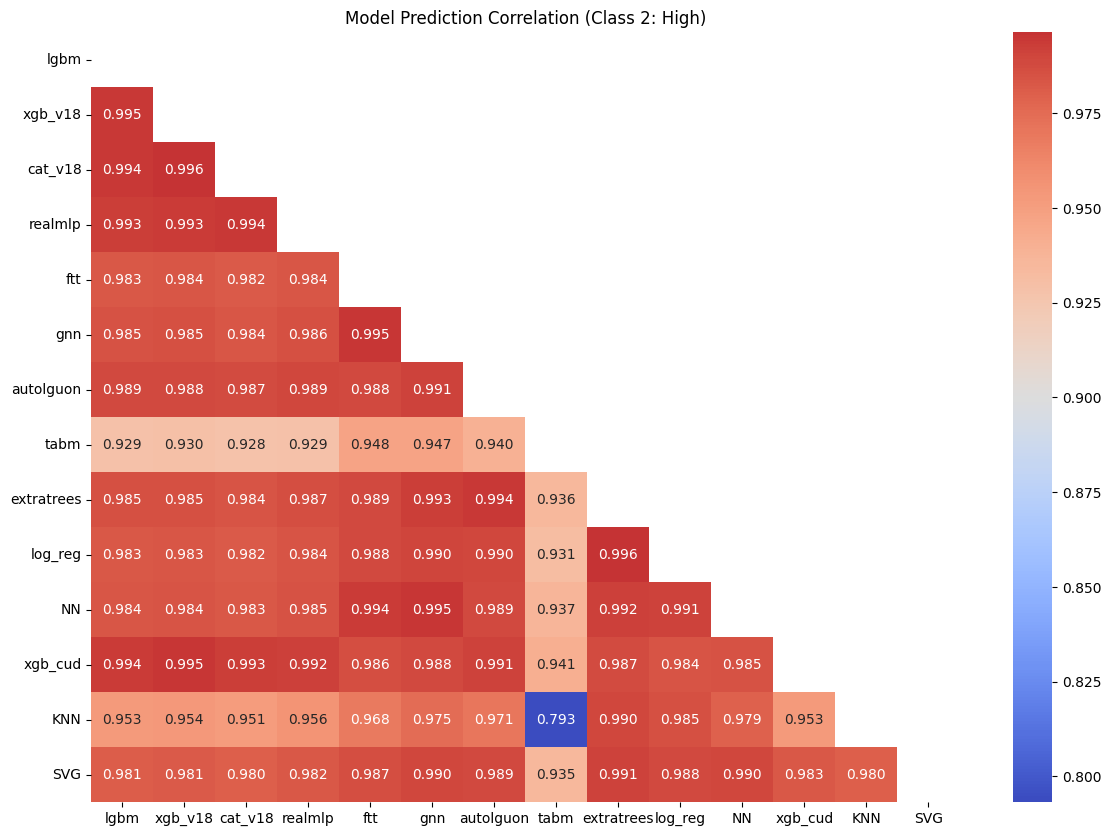


--- Redundant Models (Corr > 0.98) ---
⚠️ xgb_v18 and lgbm are 0.9947 correlated.
⚠️ cat_v18 and lgbm are 0.9943 correlated.
⚠️ cat_v18 and xgb_v18 are 0.9964 correlated.
⚠️ realmlp and lgbm are 0.9932 correlated.
⚠️ realmlp and xgb_v18 are 0.9934 correlated.
⚠️ realmlp and cat_v18 are 0.9943 correlated.
⚠️ ftt and lgbm are 0.9827 correlated.
⚠️ ftt and xgb_v18 are 0.9836 correlated.
⚠️ ftt and cat_v18 are 0.9819 correlated.
⚠️ ftt and realmlp are 0.9837 correlated.
⚠️ gnn and lgbm are 0.9846 correlated.
⚠️ gnn and xgb_v18 are 0.9854 correlated.
⚠️ gnn and cat_v18 are 0.9836 correlated.
⚠️ gnn and realmlp are 0.9857 correlated.
⚠️ gnn and ftt are 0.9951 correlated.
⚠️ autolguon and lgbm are 0.9888 correlated.
⚠️ autolguon and xgb_v18 are 0.9880 correlated.
⚠️ autolguon and cat_v18 are 0.9873 correlated.
⚠️ autolguon and realmlp are 0.9893 correlated.
⚠️ autolguon and ftt are 0.9880 correlated.
⚠️ autolguon and gnn are 0.9913 correlated.
⚠️ extratrees and lgbm are 0.9855 correlated.
⚠️

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import itertools
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder

# 1. SETUP (Ensure this matches your paths)
OOF_DIR = "/content/drive/MyDrive/irrigation_need_v15/"
train_df = pd.read_csv(f"{OOF_DIR}train.csv")
le = LabelEncoder()
y_train = le.fit_transform(train_df['Irrigation_Need'])
target_len = len(y_train)

FILES = {
    #"lgbm":      (f"{OOF_DIR}oof_lgbm_biased.npy",      f"{OOF_DIR}pred_lgbm_biased.npy"),
    "xgb_v18":   (f"{OOF_DIR}oof_xgb_v18ms.npy",       f"{OOF_DIR}pred_xgb_v18ms.npy"),
    "cat_v18":   (f"{OOF_DIR}oof_cat_v18.npy",         f"{OOF_DIR}pred_cat_v18.npy"),
    "realmlp":   (f"{OOF_DIR}oof_realmlp_biased.npy",   f"{OOF_DIR}pred_realmlp_biased.npy"),
    #"ftt":       (f"{OOF_DIR}oof_ftt_v2.npy",           f"{OOF_DIR}pred_ftt_v2.npy"),
    #"gnn":       (f"{OOF_DIR}oof_gnn_v1.npy",           f"{OOF_DIR}pred_gnn_v1.npy"),
    #"autolguon": (f"{OOF_DIR}oof_autogluon_v1.npy",     f"{OOF_DIR}pred_autogluon_v1.npy"),
    #"tabm":      (f"{OOF_DIR}oof_tabm_v5_biased.npy",   f"{OOF_DIR}pred_tabm_v5_biased.npy"),
    #"extratrees":(f"{OOF_DIR}oof_extratrees.npy",        f"{OOF_DIR}pred_extratrees.npy"),
    #"log_reg":   (f"{OOF_DIR}oof_logreg.npy",        f"{OOF_DIR}pred_logreg.npy"),
    "NN":        (f"{OOF_DIR}oof_nn_v6_enhanced.npy",  f"{OOF_DIR}pred_nn_v6_enhanced.npy"),
    #"xgb_cud":   (f"{OOF_DIR}oof_xgb_cudf_001.npy",    f"{OOF_DIR}pred_xgb_cudf_001.npy"),
    "KNN":       (f"{OOF_DIR}oof_knn_v1.npy",           f"{OOF_DIR}pred_knn_v1.npy"),
    #"SVG":       (f"{OOF_DIR}oof_svm_rbf_gpu_v1.npy",   f"{OOF_DIR}pred_svm_rbf_gpu_v1.npy"),
}

# 2. LOAD & ALIGN
model_names, aligned_oofs = [], []
print("Aligning models for correlation check...")
for name, (oof_p, _) in FILES.items():
    if os.path.exists(oof_p):
        raw = np.load(oof_p)[:target_len]
        # Align to the actual y_train classes
        best_ba, best_perm = 0, (0, 1, 2)
        for p in itertools.permutations([0, 1, 2]):
            score = balanced_accuracy_score(y_train, raw[:, p].argmax(axis=1))
            if score > best_ba:
                best_ba, best_perm = score, p
        aligned_oofs.append(raw[:, best_perm])
        model_names.append(name)

# 3. COMPUTE CORRELATION (Using Class 2 / 'High' probability)
df_corr = pd.DataFrame()
for i, name in enumerate(model_names):
    df_corr[name] = aligned_oofs[i][:, 2]

corr = df_corr.corr()

# 4. VISUALIZE
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool)) # Hide upper triangle for clarity
sns.heatmap(corr, mask=mask, annot=True, fmt=".3f", cmap='coolwarm', center=0.9)
plt.title("Model Prediction Correlation (Class 2: High)")
plt.show()

# 5. FIND CLONES (Correlation > 0.98)
print("\n--- Redundant Models (Corr > 0.98) ---")
redundant = []
for i in range(len(corr.columns)):
    for j in range(i):
        if corr.iloc[i, j] > 0.98:
            print(f"⚠️ {corr.columns[i]} and {corr.columns[j]} are {corr.iloc[i,j]:.4f} correlated.")
            redundant.append(corr.columns[i])

print("\nSUGGESTION: Try removing these redundant models and see if your Stacker CV improves!")